# Principal stresses

This notebook shows a recipe to calculate the principal stresses for a spherical source

## Import libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import utm
from datetime import datetime
from vmod.data import Gnss
from vmod.source import Mctigue

## Create Model object

In this cell we define the data points where we want to calculate the principal stresses and we create a Model object for the spherical source using the McTigue (1987) implementation.

In [2]:
xs = np.linspace(-1000,1000,10)
ys = np.linspace(-1000,1000,10)

xxs, yys = np.meshgrid(xs,ys)

obs=Gnss()
obs.add_xs(xxs.ravel())
obs.add_ys(yys.ravel())
mct = Mctigue(obs)

## Stress tensor calculation

The following lines show how to calculate the stress tensor using a certain set of parameters and diagonalize the stress tensor to obtain the magnitude and orientation of the principal stresses.

In [3]:
xcen = 0
ycen = 0
s_depth = 0
depth = 1e3
radius = 5e2
pressure = 2e-3
nu = 0.25
mu = 1

# Decompositions of the stress tensor
s1s,s2s,s3s,d1s,d2s,d3s=mct.principal_stresses(s_depth,[xcen,ycen,depth,radius,pressure,nu,mu])

## Projecting horizontal components

In this cell we obtain the horizontal components of the principal stresses.

In [4]:
# Getting the horizontal projections
s1sx=s1s*d1s[:,0]
s1sy=s1s*d1s[:,1]

s2sx=s2s*d2s[:,0]
s2sy=s2s*d2s[:,1]

s3sx=s3s*d3s[:,0]
s3sy=s3s*d3s[:,1]

## Plotting the results

In this cell we plot the most tensile and most compressive stresses

Text(0, 0.5, 'Y (km)')

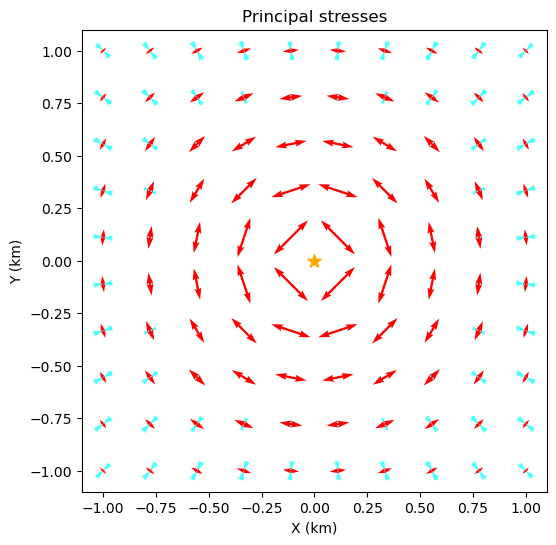

In [5]:
sc1=0.01
sc2=0.005
width=0.005

plt.figure(figsize=(6,6))
plt.title('Principal stresses')

#Plotting most compressive stresses
#Outward arrows for positive stresses
q11=plt.quiver(xxs.ravel()[s3s>0]/1e3,yys.ravel()[s3s>0]/1e3,s3sx[s3s>0],s3sy[s3s>0],alpha=0.7,scale=sc2,color='cyan', width=width)
q12=plt.quiver(xxs.ravel()[s3s>0]/1e3,yys.ravel()[s3s>0]/1e3,-s3sx[s3s>0],-s3sy[s3s>0],alpha=0.7,scale=sc2,color='cyan', width=width)
#Inward arrows for negative stresses
q13=plt.quiver(xxs.ravel()[s3s<0]/1e3,yys.ravel()[s3s<0]/1e3,-s3sx[s3s<0],-s3sy[s3s<0],alpha=0.7,scale=sc2,pivot='tip',color='cyan', width=width)
q14=plt.quiver(xxs.ravel()[s3s<0]/1e3,yys.ravel()[s3s<0]/1e3,s3sx[s3s<0],s3sy[s3s<0],alpha=0.7,scale=sc2,pivot='tip',color='cyan', width=width)

#Outward arrows for positive stresses
q=plt.quiver(xxs.ravel()[s1s>0]/1e3,yys.ravel()[s1s>0]/1e3,s1sx[s1s>0],s1sy[s1s>0],scale=sc1,color='red', width=width)
q1=plt.quiver(xxs.ravel()[s1s>0]/1e3,yys.ravel()[s1s>0]/1e3,-s1sx[s1s>0],-s1sy[s1s>0],scale=sc1,color='red', width=width)
#Inward arrows for negative stresses
q2=plt.quiver(xxs.ravel()[s1s<0]/1e3,yys.ravel()[s1s<0]/1e3,-s1sx[s1s<0],-s1sy[s1s<0],pivot='tip',scale=sc1,color='red', width=width)
q3=plt.quiver(xxs.ravel()[s1s<0]/1e3,yys.ravel()[s1s<0]/1e3,s1sx[s1s<0],s1sy[s1s<0],pivot='tip',scale=sc1,color='red', width=width)

plt.scatter(0,0,marker='*',s=100,c='orange')

plt.xlabel('X (km)')
plt.ylabel('Y (km)')